# Phase 3 — CNN Model

### Importing Libraries

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

import os, random, numpy as np
os.environ["PYTHONHASHSEED"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"       
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"       
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import tensorflow as tf
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , regularizers
from tensorflow.keras.optimizers import Adam 
from collections import Counter
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report


### Loading the Dataset

In [95]:
# loading data
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# takeing a peak at data 
display(train_df.head())


,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p35,p36,p37,p38,p39,p40,p41,p42,turn,label_move_col
0,0,1,-1,1,-1,0,1,0,1,-1,...,0,0,0,0,0,0,0,0,1,1
1,0,-1,-1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,-1,1
2,0,1,-1,1,0,0,1,0,0,-1,...,0,0,0,0,0,0,0,0,-1,2
3,1,0,0,0,-1,1,1,-1,0,0,...,0,0,0,0,0,0,0,0,-1,3
4,1,1,-1,-1,-1,1,-1,1,0,0,...,1,-1,0,0,0,0,0,1,-1,4


### Preprocessing: Convert Board DataFrame to CNN Input

Each Connect Four position is reshaped from the flattened columns (`p1`–`p42`) into a 6×7 board. 

The board values are multiplied by the player's turn (`turn` column) to align the perspective,  
so that the model always views the board from the current player's point of view.  
This ensures that the same board layout looks identical to the model regardless of whose turn it is.


After that the board is split into two channels:  
- one channel for the current player's pieces  
- one channel for the opponent's pieces  

Together, these channels provide a structured representation of the board for the model to analyze.

In [96]:
P_COLS = [f"p{i}" for i in range(1, 43)]  # p1..p42

def build_cnn_features(df):
    
    boards = df[P_COLS].to_numpy(dtype=np.int8).reshape(-1, 6, 7)      # (N,6,7)
    turns  = df["turn"].to_numpy(dtype=np.int8).reshape(-1, 1, 1)      # (N,1,1)
    boards = boards * turns                                            # normalize POV

    cur = (boards == 1).astype(np.float32)     # current player's discs
    opp = (boards == -1).astype(np.float32)    # opponent's discs
    X = np.stack([cur, opp], axis=-1)          # (N,6,7,2)

    y = None
    if  "label_move_col" in df.columns:
        y = df["label_move_col"].to_numpy(dtype=np.int64)
    return X, y

In [97]:
X_train, y_train = build_cnn_features(train_df)
X_val,   y_val   = build_cnn_features(val_df)
X_test,  _       = build_cnn_features(test_df)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
# Expect (N, 6, 7, 2) for X_* and (N,) for y_*

X_train: (49993, 6, 7, 2) y_train: (49993,)
X_val:   (10774, 6, 7, 2) y_val:   (10774,)
X_test:  (10868, 6, 7, 2)


### CNN Model Design

In [115]:
num_classes = 7
lambdaa = 5e-5     # L2 strength 
drop = 0.20   # dropout rate
lr = 1e-3     # base learning rate

# convert to one-hot for label smoothing:
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val,   num_classes)

model = keras.Sequential([
    # Input: (6,7,2)
    layers.Input(shape=(6, 7, 2)),

    # Block 1:
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Block 2
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Block 3 
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Global Average Pooling generalizes better than Flatten on tiny boards
    layers.GlobalAveragePooling2D(),

    # Classifier head with L2 + Dropout
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.Dropout(drop),


    layers.Dense(num_classes),
    layers.Softmax(name="policy")
])

model.summary()

Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_85 (Conv2D)          (None, 6, 7, 64)          1216      
                                                                 
 batch_normalization_81 (Bat  (None, 6, 7, 64)         256       
 chNormalization)                                                
                                                                 
 re_lu_81 (ReLU)             (None, 6, 7, 64)          0         
                                                                 
 conv2d_86 (Conv2D)          (None, 6, 7, 64)          36928     
                                                                 
 batch_normalization_82 (Bat  (None, 6, 7, 64)         256       
 chNormalization)                                                
                                                                 
 re_lu_82 (ReLU)             (None, 6, 7, 64)        

### Training and Evaluation

In [116]:
# Adam optimizer
opt = Adam(learning_rate=lr)

# Label smoothing reduces overconfidence and often boosts validation accuracy
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.02)

model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])


callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
]


history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=70,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/70
98/98 [==============================] - 9s 91ms/step - loss: 1.7010 - accuracy: 0.3695 - val_loss: 1.8051 - val_accuracy: 0.3674 - lr: 0.0010
Epoch 2/70
98/98 [==============================] - 8s 80ms/step - loss: 1.5153 - accuracy: 0.4454 - val_loss: 2.8488 - val_accuracy: 0.0959 - lr: 0.0010
Epoch 3/70
98/98 [==============================] - 8s 79ms/step - loss: 1.3591 - accuracy: 0.5151 - val_loss: 2.9306 - val_accuracy: 0.1231 - lr: 0.0010
Epoch 4/70
98/98 [==============================] - 9s 90ms/step - loss: 1.2715 - accuracy: 0.5501 - val_loss: 2.2788 - val_accuracy: 0.4047 - lr: 0.0010
Epoch 5/70
98/98 [==============================] - 10s 100ms/step - loss: 1.2172 - accuracy: 0.5729 - val_loss: 1.4710 - val_accuracy: 0.4934 - lr: 0.0010
Epoch 6/70
98/98 [==============================] - 10s 100ms/step - loss: 1.1705 - accuracy: 0.5922 - val_loss: 1.2881 - val_accuracy: 0.5585 - lr: 0.0010
Epoch 7/70
98/98 [==============================] - 10s 98ms/step - loss

In [136]:
# predict on validation data
y_val_pred = model.predict(X_val)
y_val_pred = y_val_pred.argmax(axis=1)

# Extract final metrics from history
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("Training accuracy:", final_train_acc)
print("Training loss:", final_train_loss)
print("Validation accuracy:", final_val_acc)
print("Validation loss:", final_val_loss)

337/337 [==============================] - 1s 4ms/step
Training accuracy: 0.7536455392837524
Training loss: 0.7690751552581787
Validation accuracy: 0.6189901828765869
Validation loss: 1.124489665031433


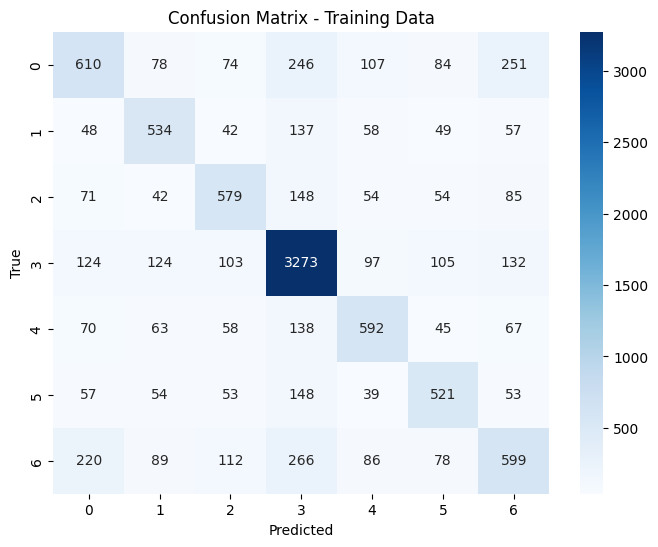

In [137]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Training Data")
plt.show()

In [126]:
# predict on test data
y_test_pred = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred , axis=1).astype(int)
Prediction = pd.DataFrame({"id": range( 1 , len(y_test_pred) +1 ), "label_move_col" : y_test_pred })
Prediction.to_csv("CNN_prediction.csv" , index = False)

340/340 [==============================] - 1s 4ms/step
